In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

SAVE_DIR = "/content/drive/MyDrive/colorectal_model"
os.makedirs(SAVE_DIR, exist_ok=True)

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay,
    precision_recall_curve, PrecisionRecallDisplay,
    classification_report
)
from tensorflow.keras.utils import to_categorical

In [4]:
# Load the dataset
data, info = tfds.load('colorectal_histology', with_info=True)

# Print available splits
print(info.features)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/colorectal_histology/incomplete.2NRUOV_2.0.0/colorectal_histology-train.tf…

Dataset colorectal_histology downloaded and prepared to /root/tensorflow_datasets/colorectal_histology/2.0.0. Subsequent calls will reuse this data.
FeaturesDict({
    'filename': Text(shape=(), dtype=string),
    'image': Image(shape=(150, 150, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=8),
})


In [33]:
train_data = data['train']

# Extract label names
class_names = info.features['label'].names

# Count number of images per class
label_counts = {i: 0 for i in range(len(class_names))}

for sample in tfds.as_numpy(train_data):
    label_counts[sample['label']] += 1

# Plot
plt.figure(figsize=(8, 5))
plt.bar(range(len(class_names)), label_counts.values(), color='teal')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.title('Distribution of Images per Class in Colorectal Histology Dataset')
plt.tight_layout()
plt.savefig('image_distribution.png') # Save the plot
plt.show()

from google.colab import files
files.download('image_distribution.png') # Download the plot

AttributeError: 'dict' object has no attribute 'features'

In [6]:
# @title
ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)


In [7]:
# Load and split dataset
(ds_train, ds_test), ds_info = tfds.load(
    'colorectal_histology',
    split=['train[:80%]', 'train[80%:]'],  # 80% train, 20% test
    as_supervised=True,                   # (image, label)
    with_info=True
)


In [8]:
IMG_SIZE = 224
BATCH_SIZE = 8

def preprocess(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

data_augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

def augment(image, label):
    image = data_augment(image)
    return image, label

train_ds = ds_train.map(preprocess).map(augment).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


Custom CNN

In [11]:
def build_custom_cnn(input_shape=(150,150,3), num_classes=8):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 5
        layers.Conv2D(512, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        # Classifier
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [12]:
model = build_custom_cnn()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    callbacks=callbacks
)


Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 78s 104ms/step - accuracy: 0.5993 - loss: 1.0593 - val_accuracy: 0.5140 - val_loss: 1.2717 - learning_rate: 1.0000e-04
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 101ms/step - accuracy: 0.7028 - loss: 0.7968 - val_accuracy: 0.7870 - val_loss: 0.5260 - learning_rate: 1.0000e-04
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 102ms/step - accuracy: 0.7347 - loss: 0.7149 - val_accuracy: 0.8480 - val_loss: 0.4539 - learning_rate: 1.0000e-04
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.7548 - loss: 0.6444 - val_accuracy: 0.8520 - val_loss: 0.4254 - learning_rate: 1.0000e-04
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 103ms/step - accuracy: 0.7890 - loss: 0.5706 - val_accuracy: 0.8080 - val_loss: 0.5012 - learning_rate: 1.0000e-04
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 101ms/step - accuracy: 0.8090 - loss: 0.5331 - val_accuracy: 0.9020 - val_loss: 0.3085 - learning_rate: 1.0000e-04
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 63s 10

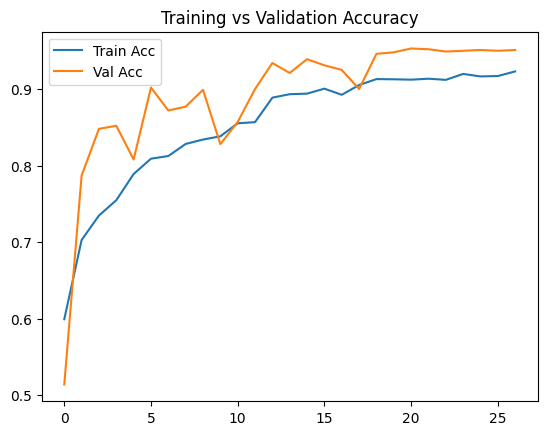

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.savefig('training_validation_accuracy.png') # Save the plot
plt.show()

from google.colab import files
files.download('training_validation_accuracy.png') # Download the plot

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━

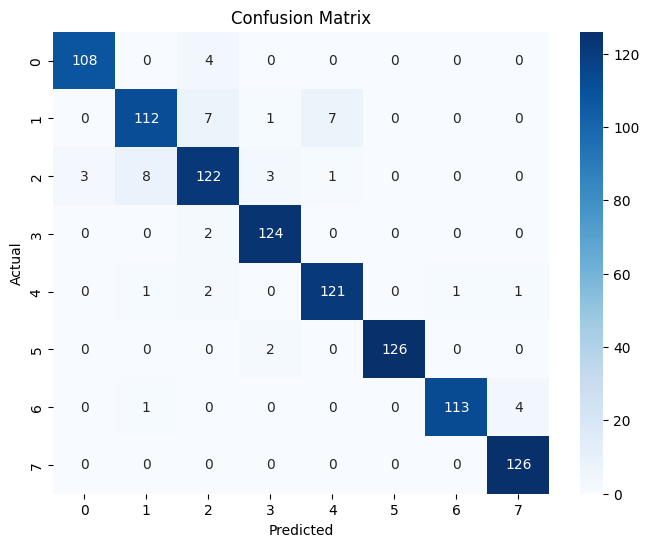

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

              precision    recall  f1-score   support

       tumor       0.97      0.96      0.97       112
      stroma       0.92      0.88      0.90       127
     complex       0.89      0.89      0.89       137
      lympho       0.95      0.98      0.97       126
      debris       0.94      0.96      0.95       126
      mucosa       1.00      0.98      0.99       128
     adipose       0.99      0.96      0.97       118
       empty       0.96      1.00      0.98       126

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('confusion_matrix.png') # Save the plot
plt.show()

from google.colab import files
files.download('confusion_matrix.png') # Download the plot

# Detailed metrics
print(classification_report(y_true, y_pred, target_names=ds_info.features['label'].names))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


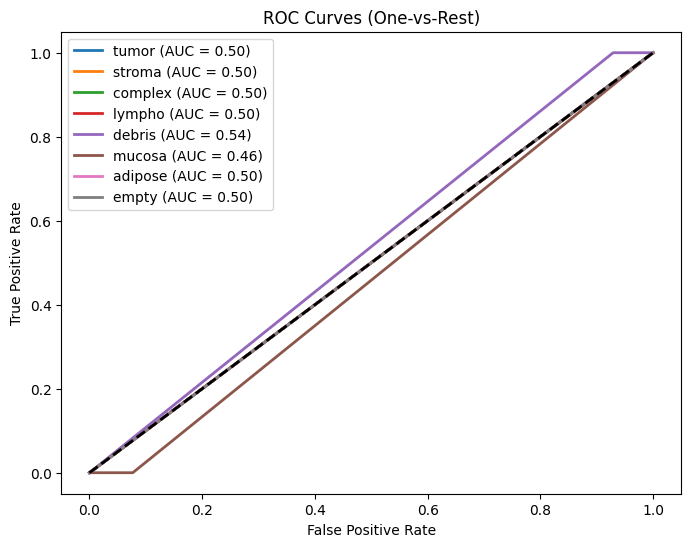

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

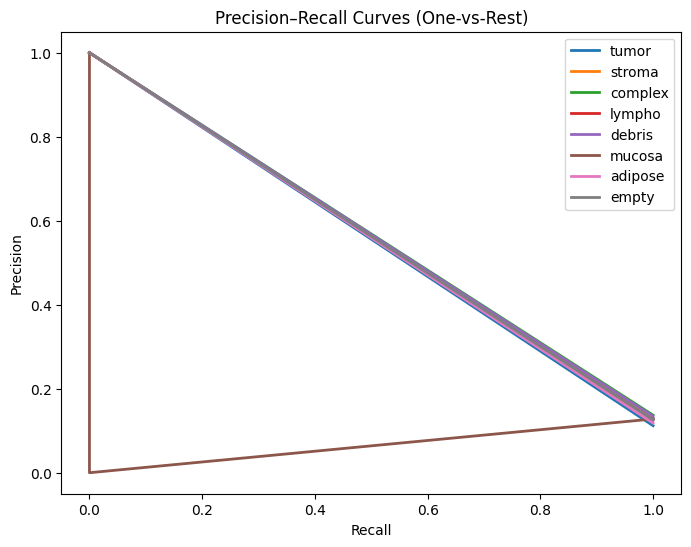

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
# --- Prepare y_true and y_pred_proba ---
y_true = []
for _, label in ds_test:
    y_true.append(label.numpy())
y_true = np.array(y_true)

# Batch the dataset before prediction
ds_test_batched = ds_test.batch(32).prefetch(tf.data.AUTOTUNE)
y_pred_proba = model.predict(ds_test_batched)

num_classes = y_pred_proba.shape[1]
class_names = ds_info.features['label'].names  # Corrected: use ds_info instead of info

# --- ROC Curves (One-vs-Rest) ---
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(to_categorical(y_true, num_classes)[:, i],
                            y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title("ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig('roc_curves.png') # Save the plot
plt.show()

from google.colab import files
files.download('roc_curves.png') # Download the plot

# --- Precision–Recall Curves (One-vs-Rest) ---
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        to_categorical(y_true, num_classes)[:, i],
        y_pred_proba[:, i]
    )
    plt.plot(recall, precision, lw=2, label=f"{class_names[i]}")

plt.title("Precision–Recall Curves (One-vs-Rest)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.savefig('precision_recall_curves.png') # Save the plot
plt.show()

files.download('precision_recall_curves.png') # Download the plot

XAI implementation

Please upload an image file for Grad-CAM analysis.


Saving colonca1001.jpg to colonca1001 (4).jpg
✅ Image 'colonca1001 (4).jpg' uploaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Class Index: 5
Predicted Class: mucosa
✅ Using last conv layer: conv2d_9
✅ Grad-CAM result saved as gradcam_result.png


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_119']]
Received: inputs=Tensor(shape=(1, 150, 150, 3))
  warnings.warn(msg)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_1317/3382042846.py:127: UserWarning: Glyph 129515 (\N{PETRI DISH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1317/3382042846.py:127: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1317/3382042846.py:128: UserWarning: Glyph 129515 (\N{PETRI DISH}) missing from font(s) DejaVu Sans.
  plt.savefig('gradcam_comparison.png') # Save the comparison plot
/tmp/ipykernel_1317/3382042846.py:128: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig('gradcam_comparison.png') # Save the comparison plot
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129515 (\N{PETRI DISH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

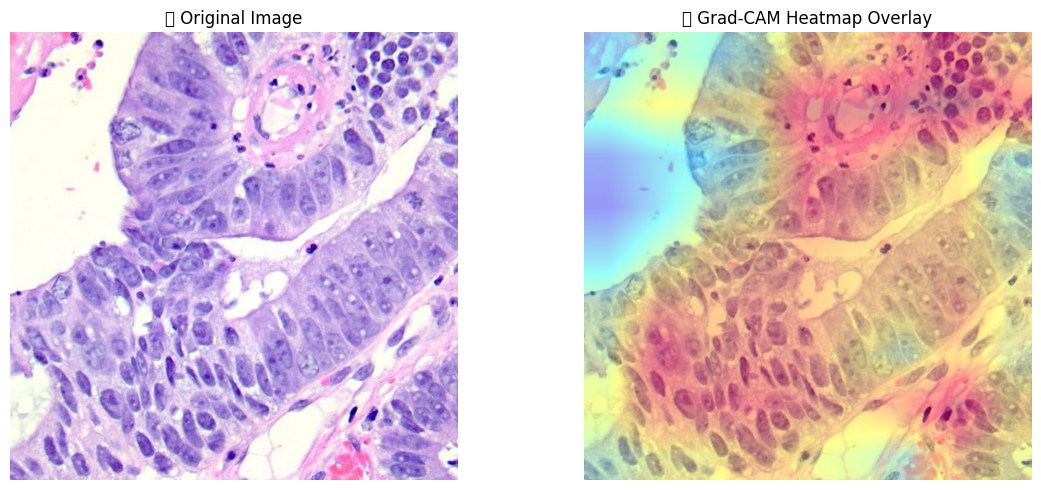

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎨 HEATMAP COLOR LEGEND:
🔵 Blue   → Low importance (model paid little attention)
🟡 Yellow → Moderate importance (some contribution)
🔴 Red    → High importance (model focused strongly here)

📊 TISSUE CLASSIFICATION: NORMAL MUCOSAL TISSUE

📝 DESCRIPTION:
   Healthy epithelial lining of the colon with normal glandular architecture and cellular organization.

🔍 WHAT THIS MEANS:
   • Normal, healthy colon lining
   • Proper glandular structure and organization
   • No evidence of dysplasia or malignancy
   • Functional absorptive and secretory tissue

🧬 POSSIBLE CAUSES / ASSOCIATIONS:
   • Normal physiological tissue — no pathological cause
   • Represents healthy baseline tissue
   • Expected finding in normal colonoscopy biopsies

⚕⚕ CLINICAL SIGNIFICANCE:
   • Reassuring finding — no pathology detected
   • Confirms absence of dysplasia or cancer in biopsied area
   • Important baseline for future comparisons
   • Indicates well-preserved tissue architecture

→→ TREATMENT INFORMATION:
  

In [42]:
# @title XAI Implementation (Grad-CAM, Visualization, and Explanation)
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from google.colab.patches import cv2_imshow
from google.colab import files
import matplotlib.pyplot as plt
import textwrap

# Ensure class_names is defined (from previous tfds.load info)
# If running this cell independently after a kernel restart, ensure `info` is available
# from a previous tfds.load call. For robustness, define it here if `info` might be lost.
# class_names = ['tumor', 'stroma', 'complex', 'lympho', 'debris', 'mucosa', 'adipose', 'empty']
# Assuming `info.features['label'].names` is already loaded from JXjadtAAz1n-

# -------------------------------
# 1❤	 Load and preprocess the image
# -------------------------------
print("Please upload an image file for Grad-CAM analysis.")
uploaded = files.upload()

if uploaded:
    img_path = list(uploaded.keys())[0]
    print(f"✅ Image '{img_path}' uploaded successfully.")
else:
    raise ValueError("❌ No image file was uploaded. Please upload an image to proceed.")

# Preprocess for model input
img_for_pred = image.load_img(img_path, target_size=(150, 150))
x = image.img_to_array(img_for_pred)
x = np.expand_dims(x, axis=0)
x /= 255.0

# -------------------------------
# 2❤	 Make a prediction
# -------------------------------
preds = model.predict(x)
predicted_class = np.argmax(preds[0])
print(f"Predicted Class Index: {predicted_class}")
predicted_label_name = class_names[predicted_class] # Use global class_names
print(f"Predicted Class: {predicted_label_name}")

# -------------------------------
# 3❤	 Identify the last Conv2D layer
# -------------------------------
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

if last_conv_layer_name is None:
    raise ValueError("❌ No Conv2D layer found in model!")
print(f"✅ Using last conv layer: {last_conv_layer_name}")

# -------------------------------
# 4❤	 Build Grad-CAM model
# -------------------------------
model_input = tf.keras.Input(shape=(150, 150, 3))
x_temp = model_input
outputs_dict = {}
for layer in model.layers:
    x_temp = layer(x_temp)
    outputs_dict[layer.name] = x_temp

functional_model = tf.keras.Model(inputs=model_input, outputs=x_temp)

grad_model = tf.keras.models.Model(
    [functional_model.inputs],
    [outputs_dict[last_conv_layer_name], functional_model.output]
)

# -------------------------------
# 5❤	 Compute Gradients (Grad-CAM)
# -------------------------------
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x)
    loss = predictions[:, predicted_class]

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

conv_outputs = conv_outputs[0]
heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)

# -------------------------------
# 6❤	 Normalize and generate heatmap
# -------------------------------
heatmap = np.maximum(heatmap, 0)
if np.max(heatmap) > 0:
    heatmap /= np.max(heatmap)
else:
    print("Warning: Max heatmap value is 0, cannot normalize. Heatmap may be empty.")

# Load original image for overlay
original_img_cv = cv2.imread(img_path)
if original_img_cv is None:
    raise FileNotFoundError(f"❌ Could not read original image at {img_path}. Please check file integrity.")

heatmap_resized = cv2.resize(heatmap, (original_img_cv.shape[1], original_img_cv.shape[0]))
heatmap_colored = np.uint8(255 * heatmap_resized)
heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(original_img_cv, 0.6, heatmap_colored, 0.4, 0)
cv2.imwrite("gradcam_result.png", superimposed_img)
print("✅ Grad-CAM result saved as gradcam_result.png")
files.download('gradcam_result.png') # Download the Grad-CAM image

# ================================================
# 7❤	 DISPLAY ORIGINAL IMAGE + HEATMAP SIDE BY SIDE
# ================================================
original_img_rgb = cv2.cvtColor(original_img_cv, cv2.COLOR_BGR2RGB)
gradcam_img_rgb = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_img_rgb)
plt.title("🧫 Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gradcam_img_rgb)
plt.title("🔥 Grad-CAM Heatmap Overlay")
plt.axis("off")

plt.tight_layout()
plt.savefig('gradcam_comparison.png') # Save the comparison plot
plt.show()
files.download('gradcam_comparison.png') # Download the comparison plot

print("\n🎨 HEATMAP COLOR LEGEND:")
print("🔵 Blue   → Low importance (model paid little attention)")
print("🟡 Yellow → Moderate importance (some contribution)")
print("🔴 Red    → High importance (model focused strongly here)\n")

# ================================================
# 8❤	 DETAILED EXPLANATION
# ================================================
# Mapping of class → explanation
tissue_explanations = {
    "mucosa": {
        "title": "NORMAL MUCOSAL TISSUE",
        "description": (
            "Healthy epithelial lining of the colon with normal glandular architecture "
            "and cellular organization."
        ),
        "meaning": [
            "Normal, healthy colon lining",
            "Proper glandular structure and organization",
            "No evidence of dysplasia or malignancy",
            "Functional absorptive and secretory tissue",
        ],
        "causes": [
            "Normal physiological tissue — no pathological cause",
            "Represents healthy baseline tissue",
            "Expected finding in normal colonoscopy biopsies",
        ],
        "clinical": [
            "Reassuring finding — no pathology detected",
            "Confirms absence of dysplasia or cancer in biopsied area",
            "Important baseline for future comparisons",
            "Indicates well-preserved tissue architecture",
        ],
        "treatment": {
            "treatable": "N/A — No treatment needed (healthy tissue)",
            "options": [
                "Continue routine screening colonoscopy per guidelines",
                "Maintain healthy lifestyle and diet",
                "High-fiber diet for colon health",
                "Regular exercise and healthy weight maintenance",
                "Limit red/processed meats, alcohol, and smoking cessation",
                "Adequate hydration and balanced nutrition",
            ],
            "prognosis": "Excellent — normal healthy tissue",
        },
        "recommendations": [
            "Age 45–50+: Screening colonoscopy every 10 years (if average risk)",
            "Family history: Earlier and more frequent screening",
            "Maintain healthy diet rich in fruits, vegetables, and whole grains",
            "Regular physical activity (≥150 min/week moderate exercise)",
            "Maintain healthy BMI",
            "Report new symptoms promptly (bleeding, pain, change in bowel habits)",
        ],
    },

    "tumor": {
        "title": "ADENOCARCINOMA / TUMOR TISSUE",
        "description": "Abnormal proliferation of epithelial cells forming irregular glands.",
        "meaning": [
            "Evidence of malignancy or pre-cancerous changes",
            "Loss of normal cellular polarity and gland structure",
            "Invasion into surrounding tissues possible",
        ],
        "causes": [
            "Genetic mutations in APC, KRAS, p53 pathways",
            "Chronic inflammation or adenomatous polyps",
        ],
        "clinical": [
            "Requires histopathological confirmation",
            "Guides further staging and treatment",
        ],
        "treatment": {
            "treatable": "Yes — with surgery, chemotherapy, and/or radiation depending on stage",
            "options": [
                "Surgical resection of affected segment",
                "Adjuvant chemotherapy (e.g., FOLFOX regimen)",
                "Targeted therapy for advanced stages",
            ],
            "prognosis": "Variable — depends on stage and differentiation",
        },
        "recommendations": [
            "Urgent referral to oncology specialist",
            "CT/MRI for staging workup",
            "Molecular profiling for targeted therapy eligibility",
        ],
    },
    # Add similar structured entries for other classes if desired:
    # "stroma", "complex", "lympho", "debris", "adipose", "empty"
}

info_explanation = tissue_explanations.get(predicted_label_name, None)

print("=" * 80)
print(f"📊 TISSUE CLASSIFICATION: {info_explanation['title'] if info_explanation else predicted_label_name.upper()}")
print("=" * 80)
if info_explanation:
    print(f"\n📝 DESCRIPTION:\n   {info_explanation['description']}\n")

    print("🔍 WHAT THIS MEANS:")
    for line in info_explanation["meaning"]:
        print(f"   • {line}")

    print("\n🧬 POSSIBLE CAUSES / ASSOCIATIONS:")
    for line in info_explanation["causes"]:
        print(f"   • {line}")

    print("\n⚕⚕ CLINICAL SIGNIFICANCE:")
    for line in info_explanation["clinical"]:
        print(f"   • {line}")

    print("\n→→ TREATMENT INFORMATION:")
    print(f"   Is it treatable? {info_explanation['treatment']['treatable']}")
    print("\n   Treatment Options:")
    for line in info_explanation["treatment"]["options"]:
        print(f"   • {line}")
    print(f"\n   ↗↗ Prognosis: {info_explanation['treatment']['prognosis']}")

    print("\n⚕‍⚕⚕ RECOMMENDATIONS:")
    for line in info_explanation["recommendations"]:
        print(f"   • {line}")
else:
    print("No detailed explanation available for this class yet.\n")

print("\n" + "=" * 80)
print("⚠️ IMPORTANT DISCLAIMER:")
print("=" * 80)
print(textwrap.dedent("""
This AI-generated explanation is for EDUCATIONAL purposes only.
It is NOT a substitute for professional medical diagnosis or treatment.
Always consult qualified healthcare providers for:
  • Definitive diagnosis and treatment planning
  • Interpretation of pathology results
  • Personalized medical advice
  • Emergency or urgent medical concerns
"""))
print("=" * 80)


In [31]:
import os
import shutil
from google.colab import files

# Define the directory to save the model
# SAVE_DIR is already defined as "/content/drive/MyDrive/colorectal_model"
# Ensure this directory exists
os.makedirs(SAVE_DIR, exist_ok=True)

model_name = "colorectal_cancer_cnn"

# --- Option 1: Save model in TensorFlow SavedModel format (recommended) ---
# This saves the model as a directory containing assets and variables
saved_model_path = os.path.join(SAVE_DIR, model_name + "_savedmodel")
model.export(saved_model_path) # Changed from model.save() to model.export()
print(f"✅ Model saved in SavedModel format to: {saved_model_path}")

# Zip the SavedModel directory for easy download
zip_path = os.path.join(SAVE_DIR, model_name + "_savedmodel.zip")
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', saved_model_path)
print(f"✅ Zipped model for download: {zip_path}")

# Provide a download link for the zipped model
files.download(zip_path)

# --- Option 2: Save model in HDF5 (.h5) format (single file) ---
# This is a common single-file format for Keras models
h5_model_path = os.path.join(SAVE_DIR, model_name + ".h5")
model.save(h5_model_path)
print(f"✅ Model saved in HDF5 format to: {h5_model_path}")

# Provide a download link for the .h5 model
files.download(h5_model_path)

print("\n⭐ Your trained model files are now available for download. Look for them in your browser's downloads.")

# --- To load the SavedModel in Python on your local machine ---
# import tensorflow as tf
# loaded_model = tf.keras.models.load_model('path/to/your/unzipped_colorectal_cancer_cnn_savedmodel')

# --- To load the HDF5 model in Python on your local machine ---
# import tensorflow as tf
# loaded_model = tf.keras.models.load_model('path/to/your/colorectal_cancer_cnn.h5')


Saved artifact at '/content/drive/MyDrive/colorectal_model/colorectal_cancer_cnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_24')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  134687472953168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134687472956240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134687472956624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134687472957392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134687472957200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134687472956816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134687472955472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134687472956432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134687472955856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134687472958544: TensorSp

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model saved in HDF5 format to: /content/drive/MyDrive/colorectal_model/colorectal_cancer_cnn.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


⭐ Your trained model files are now available for download. Look for them in your browser's downloads.


In [43]:
from google.colab import files
import os

# List of files to download (ensure these file names match the ones generated)
files_to_download = [
    'training_validation_accuracy.png',
    'confusion_matrix.png',
    'roc_curves.png',
    'precision_recall_curves.png',
    'gradcam_result.png',
    'gradcam_comparison.png',
    # Model files
    '/content/drive/MyDrive/colorectal_model/colorectal_cancer_cnn_savedmodel.zip',
    '/content/drive/MyDrive/colorectal_model/colorectal_cancer_cnn.h5'
]

print("Initiating downloads for all generated files...")
for f_path in files_to_download:
    if os.path.exists(f_path):
        try:
            files.download(f_path)
            print(f"✅ Downloaded: {f_path.split('/')[-1]}")
        except Exception as e:
            print(f"❌ Error downloading {f_path.split('/')[-1]}: {e}")
    else:
        print(f"⚠️ Warning: File not found - {f_path.split('/')[-1]}")

print("\nAll available generated files have been prompted for download.")

Initiating downloads for all generated files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: training_validation_accuracy.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: colorectal_cancer_cnn_savedmodel.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: colorectal_cancer_cnn.h5

All available generated files have been prompted for download.
